## Step 1: Importing packages and initializing the environment

In [29]:
!apt-get install -y xvfb x11-utils 2> /dev/null
%pip install pyvirtualdisplay gymnasium[toy_text] pygame 2> /dev/null

Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
x11-utils is already the newest version (7.7+5build2).
xvfb is already the newest version (2:21.1.4-2ubuntu1.7~22.04.16).
0 upgraded, 0 newly installed, 0 to remove and 3 not upgraded.


In [30]:
import gymnasium as gym
import numpy as np
import matplotlib.pyplot as plt
from tqdm.notebook import tqdm, trange
from IPython import display as ipythondisplay
from pyvirtualdisplay import Display

# Set up virtual display
virtual_display = Display(visible=0, size=(1400, 900))
virtual_display.start()

```markdown
In the **Gymnasium** library, the `render()` function is used to visualize the environment.

In Gymnasium, `render_mode` is defined during environment creation via `gymnasium.make(..., render_mode='...')`.

Common `render_mode` options:

1. **'rgb_array'**: Returns a `numpy.ndarray` (pixels), which is the standard for visualization in notebooks.
2. **'human'**: Displays the environment in a separate GUI window (not recommended for Colab).
3. **'ansi'**: Returns a text-based string representation of the environment.
```

```markdown
### Dense Reward Wrapper
In **Gymnasium**, we use a `RewardWrapper` to modify the reward signal. We must implement the `step` method to handle the standard Gymnasium return signature:
`observation, reward, terminated, truncated, info`.
```

In [31]:
class DenseReward(gym.RewardWrapper):
    def __init__(self, env):
        super().__init__(env)

    def step(self, action):
        # Gymnasium step returns 5 values
        observation, reward, terminated, truncated, info = self.env.step(action)
        self.is_done = terminated or truncated
        return observation, self.reward(reward), terminated, truncated, info

    def reward(self, reward):
        # Map rewards to be more dense
        if reward == 0:
            if self.is_done:
                return -10 # Fell in hole
            return -1      # Still moving
        else:
            return 100     # Reached goal

In [32]:
# Initialize with render_mode specified
base_env = gym.make('FrozenLake-v1', map_name="4x4", is_slippery=False, render_mode="rgb_array")
env = DenseReward(base_env)

## Step 2: Generating Episode:

Generate one episode of the environment under the given policy.



In [33]:
def generate_episode(env, policy, num_steps=100, render=False):
    steps = []
    # Gymnasium reset returns (obs, info)
    state, info = env.reset()

    for _ in range(num_steps):
        probs = policy[state]
        action = np.random.choice(np.arange(env.action_space.n), p=probs)

        # Gymnasium step returns 5 values
        next_state, reward, terminated, truncated, info = env.step(action)

        if render:
            ipythondisplay.clear_output(wait=True)
            plt.imshow(env.render())
            plt.axis('off')
            plt.show()

        steps.append((state, action, reward))
        state = next_state

        if terminated or truncated:
            break
    return steps

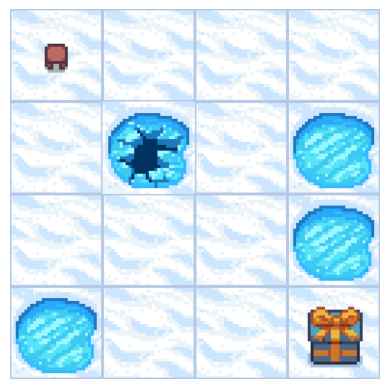

[(0, np.int64(0), -1),
 (0, np.int64(1), -1),
 (4, np.int64(3), -1),
 (0, np.int64(0), -1),
 (0, np.int64(1), -1),
 (4, np.int64(0), -1),
 (4, np.int64(1), -1),
 (8, np.int64(0), -1),
 (8, np.int64(3), -1),
 (4, np.int64(2), -10)]

In [34]:
policy = np.full((16,4), 0.25)
generate_episode(env, policy, render=True)

```markdown
## Step 3: On-policy every-visit Monte Carlo Implementation

### 3.1 Every-visit Monte Carlo Prediction
We will now use Monte Carlo methods to estimate the Value Function for a random policy in the Gymnasium environment.
```

In [35]:
def every_visit_mc_prediction(policy, episode_n, gamma, env):
    # initialize
    V = np.zeros(env.observation_space.n)
    returns = [[] for _ in range(env.observation_space.n)]
    V_hist = np.zeros((episode_n, 16))

    for i in trange(episode_n):
        # Use updated generate_episode compatible with Gymnasium
        episode = generate_episode(env, policy, render=False)
        G = 0
        for t in range(len(episode))[::-1]:
            state, action, reward = episode[t]
            G = gamma * G + reward
            returns[state].append(G)
            V[state] = np.average(returns[state])
        V_hist[i,:] = V.copy()
    return V, V_hist

In [36]:
policy = 1/4 * np.ones((16,4))
print("Starting Every-visit MC Prediction for 2000 episodes...")
V, V_hist = every_visit_mc_prediction(policy, 2000, 0.99, env)
print("Prediction complete. Results stored in V and V_hist.")

Starting Every-visit MC Prediction for 2000 episodes...


  0%|          | 0/2000 [00:00<?, ?it/s]

Prediction complete. Results stored in V and V_hist.


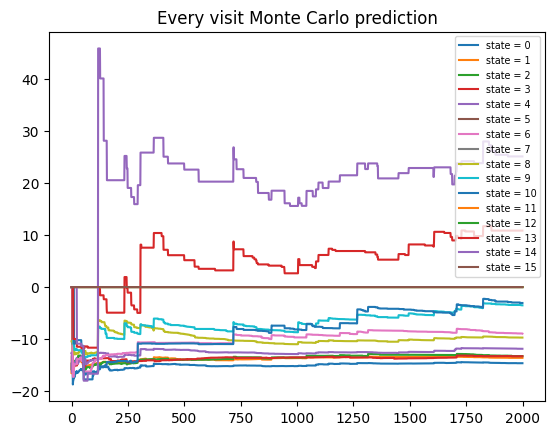

In [37]:
for i in range(16):
  plt.plot(V_hist[:,i], label = f"state = {i}")
plt.legend(loc=1, fontsize = 'x-small')
plt.title("Every visit Monte Carlo prediction")

plt.show()

In [38]:
from tabulate import tabulate
print(tabulate({f'S {round(V[0],2)}': [f'F {round(V[4],2)}', f'F {round(V[8],2)}', f'H {round(V[12],2)}'], f'F {round(V[1],2)}': [f'H {round(V[5],2)}', f'F {round(V[9],2)}', f'F {round(V[13],2)}'], f'F {round(V[2],2)}': [f'F {round(V[6],2)}', f'F {round(V[10],2)}', f'F {round(V[14],2)}'], f'F {round(V[3],2)}':[f'F {round(V[7],2)}',f'F {round(V[11],2)}',f'G {round(V[15],2)}'],}, headers="keys", tablefmt='fancy_grid', missingval='N/A'))

╒════════════╤════════════╤════════════╤════════════╕
│ S -14.66   │ F -13.63   │ F -13.29   │ F -13.32   │
╞════════════╪════════════╪════════════╪════════════╡
│ F -11.89   │ H 0.0      │ F -8.96    │ F 0.0      │
├────────────┼────────────┼────────────┼────────────┤
│ F -9.73    │ F -3.51    │ F -3.07    │ F 0.0      │
├────────────┼────────────┼────────────┼────────────┤
│ H 0.0      │ F 10.87    │ F 25.15    │ G 0.0      │
╘════════════╧════════════╧════════════╧════════════╛


### Exercise 1:

Implement first-visit Monte Carlo Prediction. Plot the value functions history.

### 3.2 First-visit Monte Carlo Prediction

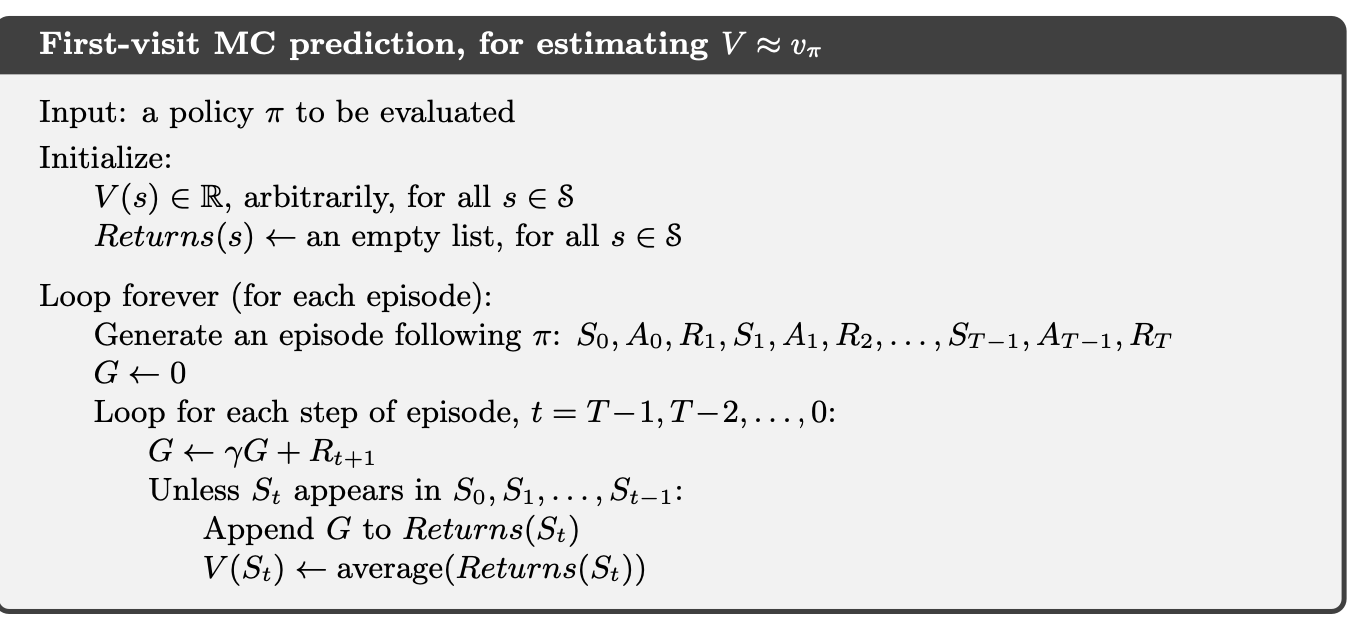

In [39]:
def first_visit_mc_prediction(policy, episode_n, gamma, env):
    V = np.zeros(env.observation_space.n)
    returns = [[] for _ in range(env.observation_space.n)]
    V_hist = np.zeros((episode_n, env.observation_space.n))

    for i in trange(episode_n):
        episode = generate_episode(env, policy, render=False)
        G = 0
        for t in range(len(episode))[::-1]:
            state, action, reward = episode[t]
            G = gamma * G + reward

            # First-visit check for V(s)
            if state not in [step[0] for step in episode[:t]]:
                returns[state].append(G)
                V[state] = np.average(returns[state])

        V_hist[i,:] = V.copy()
    return V, V_hist

In [40]:
policy= 1/4 * np.ones((16,4))
V, V_hist = first_visit_mc_prediction(policy, 5000, 0.99, env)

  0%|          | 0/5000 [00:00<?, ?it/s]

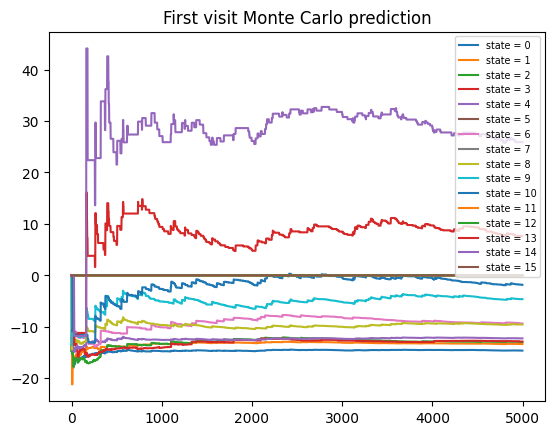

In [41]:
for i in range(16):
  plt.plot(V_hist[:,i], label = f"state = {i}")
plt.legend(loc=1, fontsize = 'x-small')
plt.title("First visit Monte Carlo prediction")

plt.show()

In [42]:
from tabulate import tabulate
print(tabulate({f'S {round(V[0],2)}': [f'F {round(V[4],2)}', f'F {round(V[8],2)}', f'H {round(V[12],2)}'], f'F {round(V[1],2)}': [f'H {round(V[5],2)}', f'F {round(V[9],2)}', f'F {round(V[13],2)}'], f'F {round(V[2],2)}': [f'F {round(V[6],2)}', f'F {round(V[10],2)}', f'F {round(V[14],2)}'], f'F {round(V[3],2)}':[f'F {round(V[7],2)}',f'F {round(V[11],2)}',f'G {round(V[15],2)}'],}, headers="keys", tablefmt='fancy_grid', missingval='N/A'))

╒════════════╤════════════╤════════════╤════════════╕
│ S -14.62   │ F -13.35   │ F -12.96   │ F -12.86   │
╞════════════╪════════════╪════════════╪════════════╡
│ F -12.25   │ H 0.0      │ F -9.35    │ F 0.0      │
├────────────┼────────────┼────────────┼────────────┤
│ F -9.55    │ F -4.62    │ F -1.83    │ F 0.0      │
├────────────┼────────────┼────────────┼────────────┤
│ H 0.0      │ F 7.66     │ F 25.9     │ G 0.0      │
╘════════════╧════════════╧════════════╧════════════╛


### 3.3 Every-visit Monte Carlo Control

In [43]:
def every_visit_MC(env, num_episodes, gamma=0.9, epsilon=0.3):
    # Initializtion
    undiscounted_returns = []
    n_states = env.observation_space.n
    n_actions = env.action_space.n
    policy = np.ones((n_states, n_actions)) * (1/n_actions)
    Q = np.zeros((n_states, n_actions))
    Returns = [[[] for _ in range(n_actions)] for _ in range(n_states)]

    for i in tqdm(range(num_episodes)):
        episode = generate_episode(env, policy, render=False)
        G = 0
        undis_return = sum([step[2] for step in episode])

        for state, action, reward in episode[::-1]:
           G = gamma * G + reward
           Returns[state][action].append(G)
           Q[state, action] = np.mean(Returns[state][action])

           # Policy Improvement
           a_max = np.argmax(Q[state])
           for a in range(n_actions):
                if (a == a_max):
                    policy[state, a] = 1.0 - epsilon + (epsilon / n_actions)
                else:
                    policy[state, a] = epsilon / n_actions

        undiscounted_returns.append(undis_return)
    return policy, undiscounted_returns

In [44]:
num_episodes = 2000
ev_MC_policy, ev_MC_returns = every_visit_MC(env, num_episodes)

  0%|          | 0/2000 [00:00<?, ?it/s]

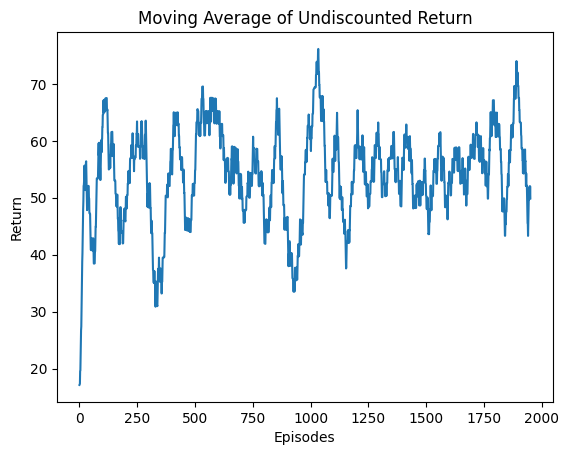

In [45]:
# Calculate a moving average over 50 episodes
window_size = 50
moving_avg = np.convolve(ev_MC_returns, np.ones(window_size)/window_size, mode='valid')

plt.plot(moving_avg)
plt.title("Moving Average of Undiscounted Return")
plt.xlabel("Episodes")
plt.ylabel("Return")
plt.show()

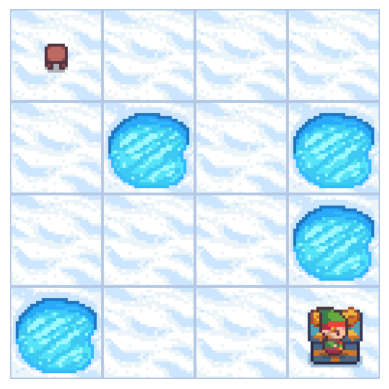

[(0, np.int64(2), -1),
 (1, np.int64(2), -1),
 (2, np.int64(1), -1),
 (6, np.int64(1), -1),
 (10, np.int64(1), -1),
 (14, np.int64(2), 100)]

In [46]:
generate_episode(env, ev_MC_policy, render=True)

### Exercise 2:

Implement on-policy first-visit Monte Carlo algorithm.

### On-policy first-visit MC

In [47]:
def first_visit_MC(episodes_n=2000, env=env, gamma=0.9, epsilon=0.3):
    undiscounted_returns = []
    n_states = env.observation_space.n
    n_actions = env.action_space.n
    policy = np.full((n_states, n_actions), 1/n_actions)
    Q = np.zeros((n_states, n_actions))
    Returns = [[[] for _ in range(n_actions)] for _ in range(n_states)]

    for i in tqdm(range(episodes_n)):
        episode = generate_episode(env, policy)
        G = 0
        undis_return = sum([step[2] for step in episode])

        visited_state_actions = set()
        for t in range(len(episode)-1, -1, -1):
            state, action, reward = episode[t]
            G = gamma * G + reward

            # Check if this is the first visit to (s, a) in this episode
            if (state, action) not in [(episode[k][0], episode[k][1]) for k in range(t)]:
                Returns[state][action].append(G)
                Q[state, action] = np.mean(Returns[state][action])

                # Epsilon-greedy policy improvement
                a_max = np.argmax(Q[state])
                for a in range(n_actions):
                    if a == a_max:
                        policy[state, a] = 1.0 - epsilon + (epsilon / n_actions)
                    else:
                        policy[state, a] = epsilon / n_actions

        undiscounted_returns.append(undis_return)
    return policy, undiscounted_returns

In [ ]:
num_episodes = 5000
fv_MC_policy, fv_MC_returns = first_visit_MC(num_episodes, env)

  0%|          | 0/5000 [00:00<?, ?it/s]

In [ ]:
# Calculate a moving average over 50 episodes
window_size = 50
moving_avg = np.convolve(fv_MC_returns, np.ones(window_size)/window_size, mode='valid')

plt.plot(moving_avg)
plt.title("Moving Average of Undiscounted Return")
plt.xlabel("Episodes")
plt.ylabel("Return")
plt.show()

In [ ]:
generate_episode(env, fv_MC_policy, render=True)

## Off-policy Weighted MC

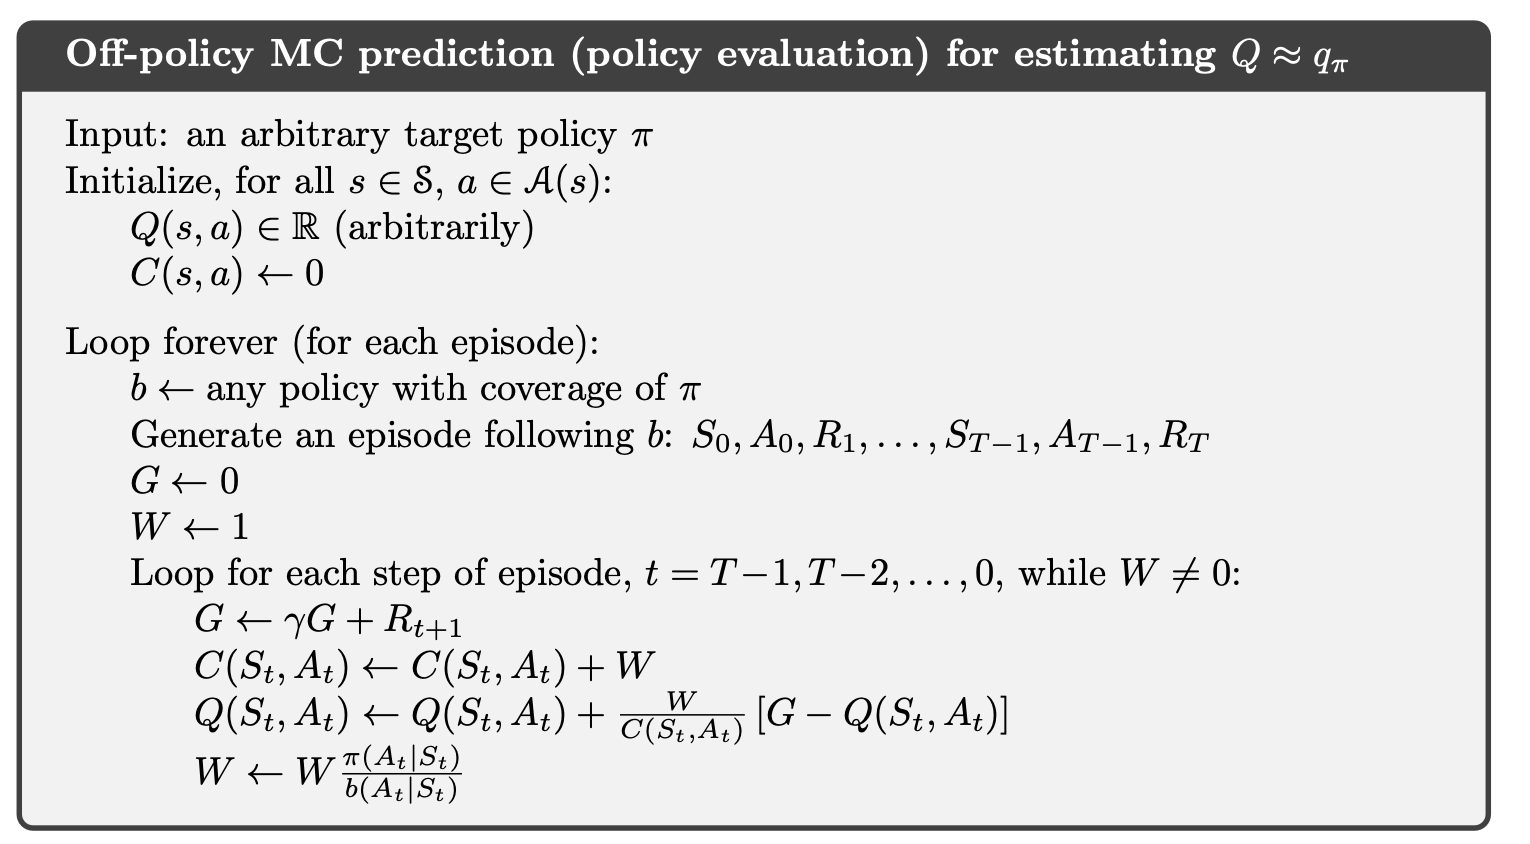

In [ ]:
# Behavior Policy
b = np.ones((env.observation_space.n,env.action_space.n)) * (1/env.action_space.n)

In [ ]:
def weighted_IS_MC(env, behavior_policy, target_policy, num_episodes, gamma):
    V = np.zeros(env.observation_space.n)
    C = np.zeros(env.observation_space.n)
    V_hist = np.zeros((num_episodes, env.observation_space.n))

    for i in range(num_episodes):
        # gymnasium compatible episode generation
        episode = generate_episode(env, behavior_policy, render=False)
        G = 0.0
        W = 1.0

        for t in range(len(episode))[::-1]:
            state, action, reward = episode[t]
            G = gamma * G + reward
            C[state] += W
            V[state] += (W / C[state]) * (G - V[state])

            # Update W based on importance sampling ratio
            W *= target_policy[state, action] / behavior_policy[state, action]
            if W == 0:
                break

        V_hist[i] = V.copy()

    return V, V_hist

In [ ]:
# Wrapper for Weighted IS
def v_s_weighted(s):
    V_hist_weighted_s = np.zeros((10, 2000))
    for i in range(10):
        # Using the same target policy (ev_MC_policy) and behavior policy (b)
        V_weighted, V_hist_weighted = weighted_IS_MC(env, ev_MC_policy, b, 2000, 0.99)
        V_hist_weighted_s[i,:] = V_hist_weighted[:,s]
    return V_hist_weighted_s

In [ ]:
def plot_many(experiments, label, color):
    mean_exp = np.mean(experiments, axis=0)
    std_exp = np.std(experiments, axis=0)
    plt.plot(mean_exp, color=color, label=label)
    plt.fill_between(range(len(experiments[0])), mean_exp + std_exp,
        mean_exp - std_exp, color=color, alpha=0.1)

In [ ]:
# Plot State 1
plt.figure(figsize=(10, 5))
V_hist_s_1_weighted = v_s_weighted(1)

plot_many(V_hist_s_1_weighted, "Weighted IS", "blue")
plt.title("Off-Policy MC Prediction: State 1")
plt.legend()
plt.show()

In [ ]:
# Plot State 14
plt.figure(figsize=(10, 5))
V_hist_s_14_weighted = v_s_weighted(14)

plot_many(V_hist_s_14_weighted, "Weighted IS", "blue")
plt.title("Off-Policy MC Prediction: State 14")
plt.legend()
plt.show()

### Exercise 3:

Implement Monte Carlo methods for FrozenLake with `is_slippery=True`